##Install Packages

In [5]:
!pip install -q split-folders

##Import Libraries

In [6]:
import os, zipfile, shutil, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score
)

warnings.filterwarnings("ignore")
print("Imports done")

Imports done


##Mount Drive + Set Device + Reproducibility

In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Mounted at /content/drive
Device: cuda


In [8]:
ZIP_PATH = "/content/archive (2).zip"
EXTRACT_DIR = "/content/raw_data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

TRAIN_SRC = None
for root, dirs, _ in os.walk(EXTRACT_DIR):
    if "Closed" in dirs and "Open" in dirs and "yawn" in dirs:
        TRAIN_SRC = root
        break

print("Train folder:", TRAIN_SRC)
print("Classes:", sorted(os.listdir(TRAIN_SRC)))

Train folder: /content/raw_data/train
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


##Split Data

In [9]:
import splitfolders

SPLIT_DIR = "/content/dataset_split"
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(TRAIN_SRC, output=SPLIT_DIR, seed=SEED, ratio=(0.70, 0.15, 0.15))

for split in ["train", "val", "test"]:
    print(split)
    for cls in sorted(os.listdir(f"{SPLIT_DIR}/{split}")):
        n = len(os.listdir(f"{SPLIT_DIR}/{split}/{cls}"))
        print("  ", cls, ":", n)

Copying files: 2900 files [00:00, 4845.29 files/s]

train
   Closed : 508
   Open : 508
   no_yawn : 507
   yawn : 506
val
   Closed : 108
   Open : 108
   no_yawn : 108
   yawn : 108
test
   Closed : 110
   Open : 110
   no_yawn : 110
   yawn : 109


##EDA

##EDA 1 — Class Distribution Table

         train  val  test
Closed     508  108   110
Open       508  108   110
no_yawn    507  108   110
yawn       506  108   109


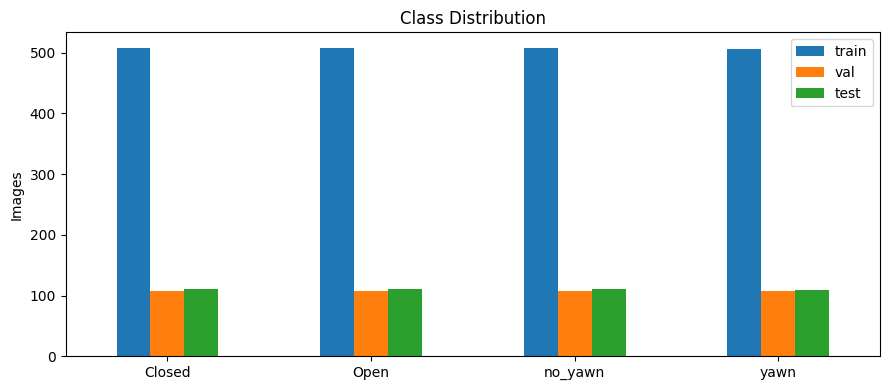

In [10]:
classes = sorted(os.listdir(f"{SPLIT_DIR}/train"))

counts = {s: [len(os.listdir(f"{SPLIT_DIR}/{s}/{c}")) for c in classes]
          for s in ["train", "val", "test"]}
df = pd.DataFrame(counts, index=classes)
print(df)

df.plot(kind="bar", figsize=(9, 4))
plt.title("Class Distribution")
plt.ylabel("Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##EDA 2 — Sample Image Grid (Visual Check)

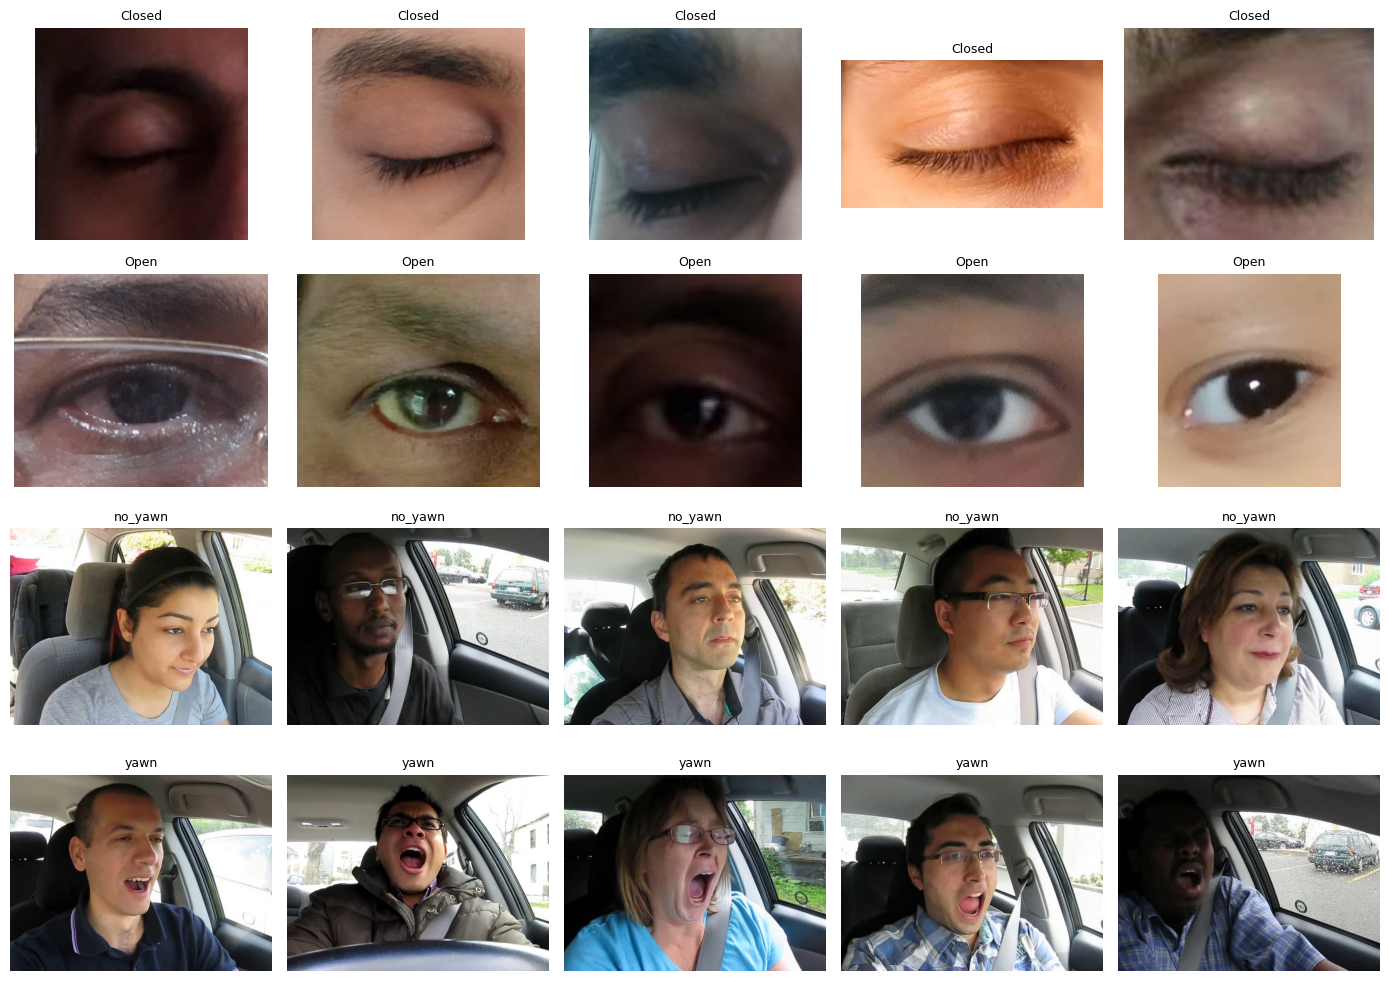

In [11]:
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
for i, cls in enumerate(classes):
    for j, p in enumerate(random.sample(glob.glob(f"{SPLIT_DIR}/train/{cls}/*"), 5)):
        axes[i, j].imshow(Image.open(p))
        axes[i, j].axis("off")
        axes[i, j].set_title(cls, fontsize=9)
plt.tight_layout()
plt.show()

##EDA 3 — Image Size Distribution

Width  min/max/mean: 67 1365 483
Height min/max/mean: 58 1365 389


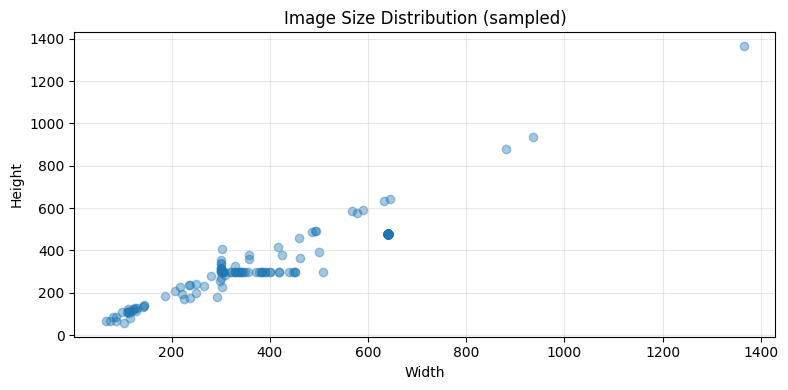

In [12]:
sizes = []
for cls in classes:
    for p in random.sample(glob.glob(f"{SPLIT_DIR}/train/{cls}/*"), 50):
        sizes.append(Image.open(p).size)

w = [s[0] for s in sizes]
h = [s[1] for s in sizes]

print("Width  min/max/mean:", min(w), max(w), int(np.mean(w)))
print("Height min/max/mean:", min(h), max(h), int(np.mean(h)))

plt.figure(figsize=(8, 4))
plt.scatter(w, h, alpha=0.4)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution (sampled)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##EDA 4 — Pixel Intensity per Class

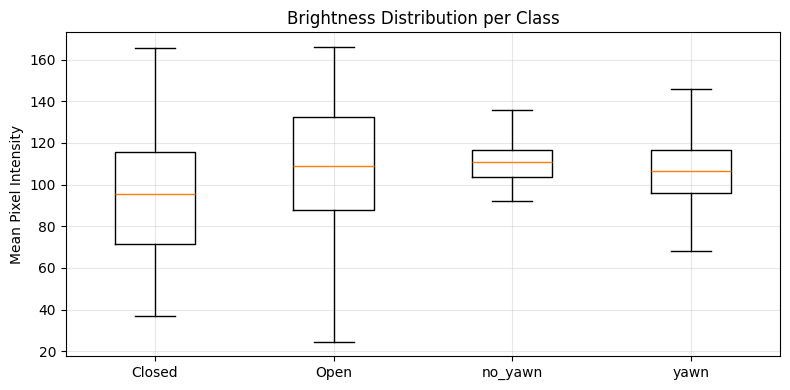

In [13]:
means = {}
for cls in classes:
    vals = []
    for p in random.sample(glob.glob(f"{SPLIT_DIR}/train/{cls}/*"), 30):
        vals.append(np.array(Image.open(p).convert("L")).mean())
    means[cls] = vals

plt.figure(figsize=(8, 4))
plt.boxplot([means[c] for c in classes], labels=classes)
plt.ylabel("Mean Pixel Intensity")
plt.title("Brightness Distribution per Class")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##Data Preprocessing

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

###Training Transform

In [20]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

###Validation / Test Transform

In [21]:
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

##Dataset Class

In [22]:
class DrowsinessDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        self.classes = sorted(os.listdir(root))
        for i, c in enumerate(self.classes):
            for p in glob.glob(f"{root}/{c}/*"):
                self.samples.append((p, i))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

##Create Datasets

In [23]:
train_ds = DrowsinessDataset(f"{SPLIT_DIR}/train", train_tf)
val_ds = DrowsinessDataset(f"{SPLIT_DIR}/val", eval_tf)
test_ds = DrowsinessDataset(f"{SPLIT_DIR}/test", eval_tf)

##DataLoaders

In [24]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [25]:
CLASSES = train_ds.classes
print("Classes:", CLASSES)
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

x, y = next(iter(train_loader))
print("Batch shape:", x.shape)
print("Labels shape:", y.shape)

Classes: ['Closed', 'Open', 'no_yawn', 'yawn']
Train: 2029 Val: 432 Test: 439
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


##Custom CNN

In [26]:
class CustomCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

custom_cnn = CustomCNN().to(DEVICE)
print("Custom CNN params:", sum(p.numel() for p in custom_cnn.parameters()))

Custom CNN params: 422788


##MobileNetV2

In [27]:
def build_mobilenetv2(n_classes=4):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    for p in model.features.parameters():
        p.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(128, n_classes)
    )
    return model

mobilenet = build_mobilenetv2().to(DEVICE)
print("MobileNetV2 trainable params:", sum(p.numel() for p in mobilenet.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 109MB/s]

MobileNetV2 trainable params: 164484


##Training Helper Functions

In [28]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return loss_sum / n, correct / n

##Evaluation Function

In [29]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return loss_sum / n, correct / n

##Fit Function (Train Loop)

In [30]:
def fit(model, epochs, lr, ckpt):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_acc, wait = 0, 0
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(tl)
        hist["train_acc"].append(ta)
        hist["val_loss"].append(vl)
        hist["val_acc"].append(va)
        print(f"Epoch {ep:02d} | train_loss {tl:.4f} acc {ta:.4f} | val_loss {vl:.4f} acc {va:.4f}")

        if va > best_acc:
            best_acc, wait = va, 0
            torch.save(model.state_dict(), ckpt)
        else:
            wait += 1
            if wait >= 5:
                print("Early stopping")
                break

    model.load_state_dict(torch.load(ckpt))
    return hist

##Train Custom CNN

In [32]:
print("Training Custom CNN")
hist_cnn = fit(custom_cnn, epochs=16, lr=1e-3, ckpt="custom_cnn.pt")

Training Custom CNN
Epoch 01 | train_loss 0.4118 acc 0.7817 | val_loss 0.4289 acc 0.7963
Epoch 02 | train_loss 0.4179 acc 0.7787 | val_loss 0.4495 acc 0.7870
Epoch 03 | train_loss 0.4231 acc 0.7861 | val_loss 0.5286 acc 0.7546
Epoch 04 | train_loss 0.4086 acc 0.7836 | val_loss 0.4114 acc 0.8102
Epoch 05 | train_loss 0.4069 acc 0.7915 | val_loss 0.7246 acc 0.7060
Epoch 06 | train_loss 0.3999 acc 0.7777 | val_loss 0.4384 acc 0.7847
Epoch 07 | train_loss 0.4066 acc 0.7807 | val_loss 0.4225 acc 0.7917
Epoch 08 | train_loss 0.3778 acc 0.8029 | val_loss 0.4706 acc 0.7407
Epoch 09 | train_loss 0.3929 acc 0.7827 | val_loss 0.3972 acc 0.8056
Early stopping


Train MobileNetV2 (Frozen Base)

In [33]:
print("Training MobileNetV2")
hist_mnv2 = fit(mobilenet, epochs=15, lr=1e-3, ckpt="mobilenetv2.pt")

Training MobileNetV2
Epoch 01 | train_loss 0.6643 acc 0.6767 | val_loss 0.3504 acc 0.8611
Epoch 02 | train_loss 0.4302 acc 0.7871 | val_loss 0.3169 acc 0.8079
Epoch 03 | train_loss 0.3822 acc 0.8172 | val_loss 0.2863 acc 0.9028
Epoch 04 | train_loss 0.3422 acc 0.8241 | val_loss 0.2660 acc 0.9120
Epoch 05 | train_loss 0.3495 acc 0.8403 | val_loss 0.2731 acc 0.8380
Epoch 06 | train_loss 0.3348 acc 0.8344 | val_loss 0.2524 acc 0.9028
Epoch 07 | train_loss 0.3281 acc 0.8448 | val_loss 0.2493 acc 0.9120
Epoch 08 | train_loss 0.3475 acc 0.8300 | val_loss 0.2648 acc 0.8611
Epoch 09 | train_loss 0.3094 acc 0.8546 | val_loss 0.2255 acc 0.9144
Epoch 10 | train_loss 0.3200 acc 0.8448 | val_loss 0.2629 acc 0.8681
Epoch 11 | train_loss 0.3114 acc 0.8586 | val_loss 0.2206 acc 0.9213
Epoch 12 | train_loss 0.2946 acc 0.8571 | val_loss 0.2345 acc 0.8958
Epoch 13 | train_loss 0.3115 acc 0.8561 | val_loss 0.2166 acc 0.9236
Epoch 14 | train_loss 0.3070 acc 0.8507 | val_loss 0.2176 acc 0.9282
Epoch 15 | tr

##Fine-Tune MobileNetV2 (Unfreeze Top Layers)

In [34]:
for p in mobilenet.features[-4:].parameters():
    p.requires_grad = True

print("Fine-tuning MobileNetV2")
hist_fine = fit(mobilenet, epochs=8, lr=1e-5, ckpt="mobilenetv2_ft.pt")

Fine-tuning MobileNetV2
Epoch 01 | train_loss 0.2883 acc 0.8600 | val_loss 0.1823 acc 0.9630
Epoch 02 | train_loss 0.2475 acc 0.8866 | val_loss 0.1579 acc 0.9537
Epoch 03 | train_loss 0.1967 acc 0.9211 | val_loss 0.1316 acc 0.9653
Epoch 04 | train_loss 0.1855 acc 0.9251 | val_loss 0.1117 acc 0.9745
Epoch 05 | train_loss 0.1568 acc 0.9335 | val_loss 0.0973 acc 0.9745
Epoch 06 | train_loss 0.1401 acc 0.9423 | val_loss 0.0846 acc 0.9745
Epoch 07 | train_loss 0.1344 acc 0.9483 | val_loss 0.0813 acc 0.9769
Epoch 08 | train_loss 0.1180 acc 0.9571 | val_loss 0.0731 acc 0.9792


##Plot Training History

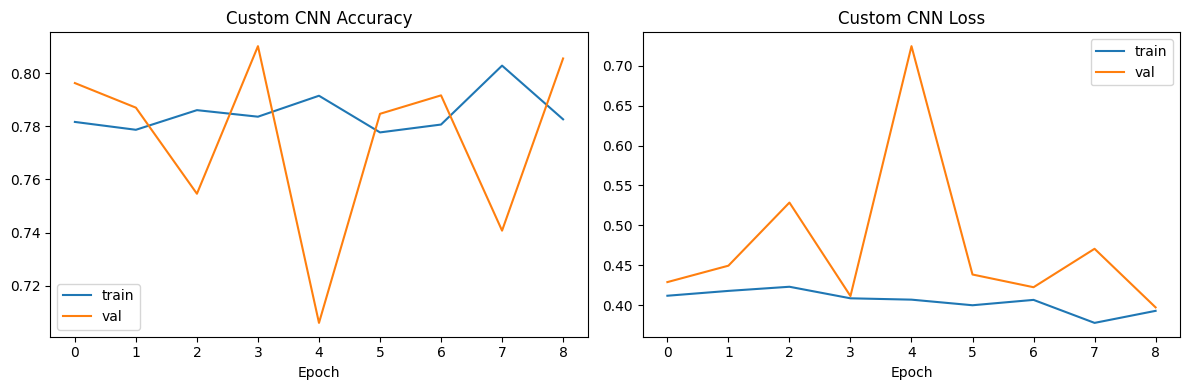

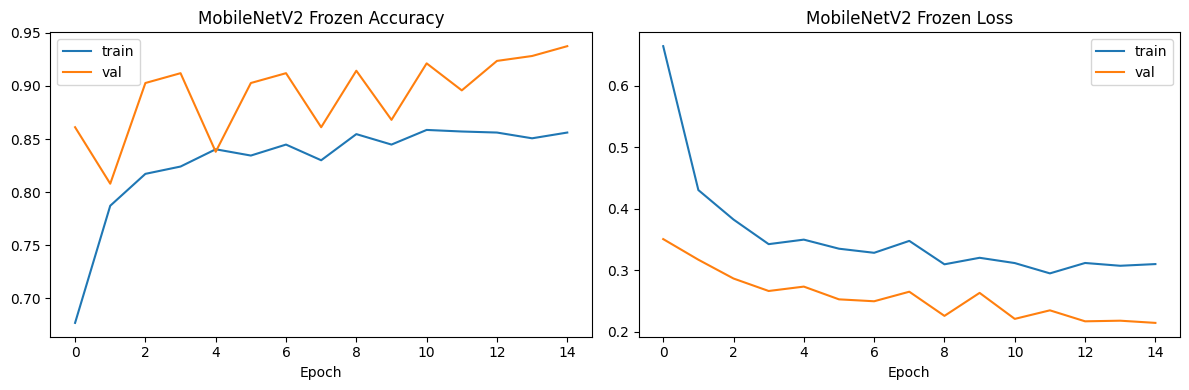

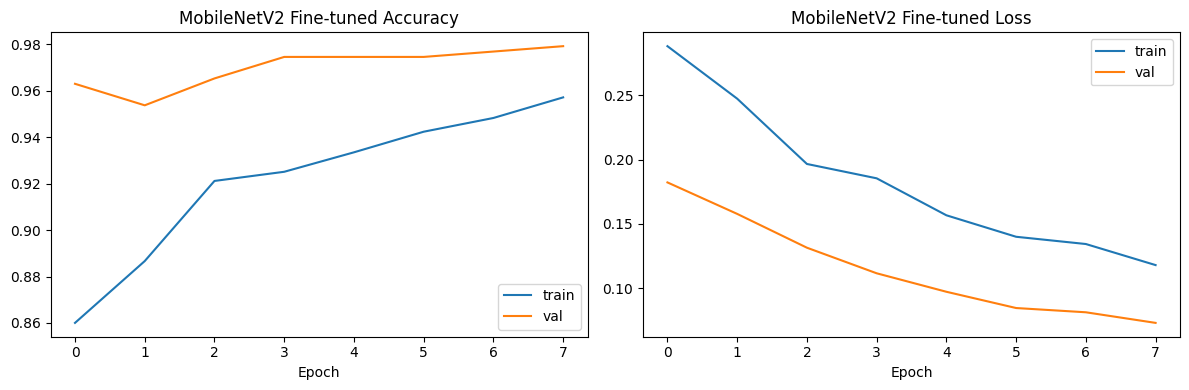

In [35]:
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["train_acc"], label="train")
    ax[0].plot(h["val_acc"], label="val")
    ax[0].set_title(f"{title} Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[1].plot(h["train_loss"], label="train")
    ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(f"{title} Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_cnn, "Custom CNN")
plot_history(hist_mnv2, "MobileNetV2 Frozen")
plot_history(hist_fine, "MobileNetV2 Fine-tuned")

##Prediction Helper

In [36]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        out = model(x.to(DEVICE))
        preds.append(out.argmax(1).cpu().numpy())
        trues.append(y.numpy())
    return np.concatenate(preds), np.concatenate(trues)

##Evaluation Function

In [37]:
def evaluate_model(model, name):
    y_pred, y_true = get_preds(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=CLASSES))
    acc = (y_pred == y_true).mean()
    print(f"Test Accuracy ({name}): {acc:.4f}\n")
    return acc

##Evaluate Both Models

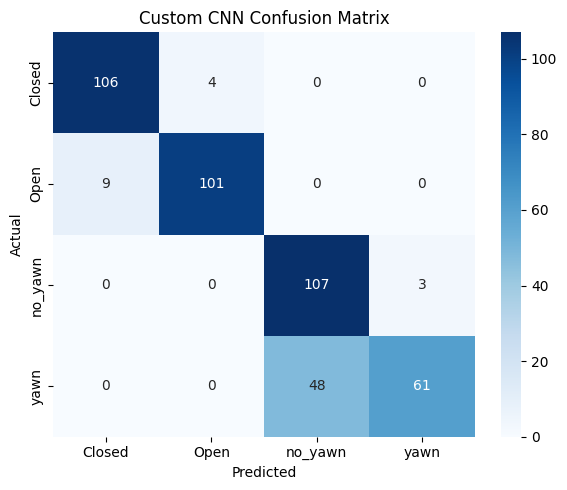

              precision    recall  f1-score   support

      Closed       0.92      0.96      0.94       110
        Open       0.96      0.92      0.94       110
     no_yawn       0.69      0.97      0.81       110
        yawn       0.95      0.56      0.71       109

    accuracy                           0.85       439
   macro avg       0.88      0.85      0.85       439
weighted avg       0.88      0.85      0.85       439

Test Accuracy (Custom CNN): 0.8542



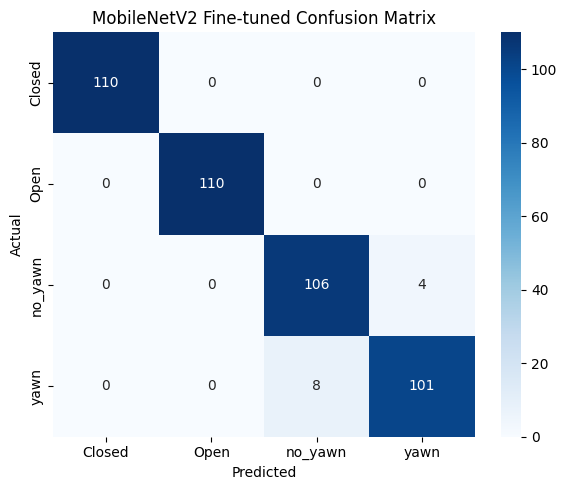

              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       110
        Open       1.00      1.00      1.00       110
     no_yawn       0.93      0.96      0.95       110
        yawn       0.96      0.93      0.94       109

    accuracy                           0.97       439
   macro avg       0.97      0.97      0.97       439
weighted avg       0.97      0.97      0.97       439

Test Accuracy (MobileNetV2 Fine-tuned): 0.9727

                    Model  Test Accuracy
0              Custom CNN       0.854214
1  MobileNetV2 Fine-tuned       0.972665


In [38]:
acc_cnn = evaluate_model(custom_cnn, "Custom CNN")
acc_mnv2 = evaluate_model(mobilenet, "MobileNetV2 Fine-tuned")

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2 Fine-tuned"],
    "Test Accuracy": [acc_cnn, acc_mnv2]
})
print(comparison)

##3-Level Fatigue Fusion Logic

In [39]:
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
print("Class mapping:", CLS2IDX)

IDX2STAGE = {
    CLS2IDX["Open"]:    0,
    CLS2IDX["no_yawn"]: 0,
    CLS2IDX["yawn"]:    1,
    CLS2IDX["Closed"]:  2
}
STAGE_LABELS = ["Alert", "Mild Fatigue", "Severe Fatigue"]

@torch.no_grad()
def predict_fatigue(image_path, model):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(DEVICE)
    probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    pred_idx = int(np.argmax(probs))
    stage = IDX2STAGE[pred_idx]
    return {
        "file": os.path.basename(image_path),
        "pred_class": CLASSES[pred_idx],
        "stage": stage,
        "stage_label": STAGE_LABELS[stage],
        "confidence": round(float(probs[pred_idx]), 3)
    }

Class mapping: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


##Demo on Test Samples

In [40]:
for cls in CLASSES:
    p = random.choice(glob.glob(f"{SPLIT_DIR}/test/{cls}/*"))
    print(predict_fatigue(p, mobilenet))

{'file': '_15.jpg', 'pred_class': 'Closed', 'stage': 2, 'stage_label': 'Severe Fatigue', 'confidence': 1.0}
{'file': '_325.jpg', 'pred_class': 'Open', 'stage': 0, 'stage_label': 'Alert', 'confidence': 1.0}
{'file': '1783.jpg', 'pred_class': 'no_yawn', 'stage': 0, 'stage_label': 'Alert', 'confidence': 0.867}
{'file': '246.jpg', 'pred_class': 'yawn', 'stage': 1, 'stage_label': 'Mild Fatigue', 'confidence': 1.0}


##Fatigue Progression Curve

In [41]:
def simulate_session(model, paths, frames_per_min=30):
    stages = [predict_fatigue(p, model)["stage"] for p in paths]
    minutes = [np.mean(stages[i:i + frames_per_min])
               for i in range(0, len(stages), frames_per_min)]
    return minutes

##Build Synthetic Driving Session

In [42]:
session = []
session += random.choices(glob.glob(f"{SPLIT_DIR}/test/Open/*"),   k=180)
session += random.choices(glob.glob(f"{SPLIT_DIR}/test/yawn/*"),   k=120)
session += random.choices(glob.glob(f"{SPLIT_DIR}/test/Closed/*"), k=180)

print("Total frames:", len(session))

Total frames: 480


##Generate and Plot the Curve

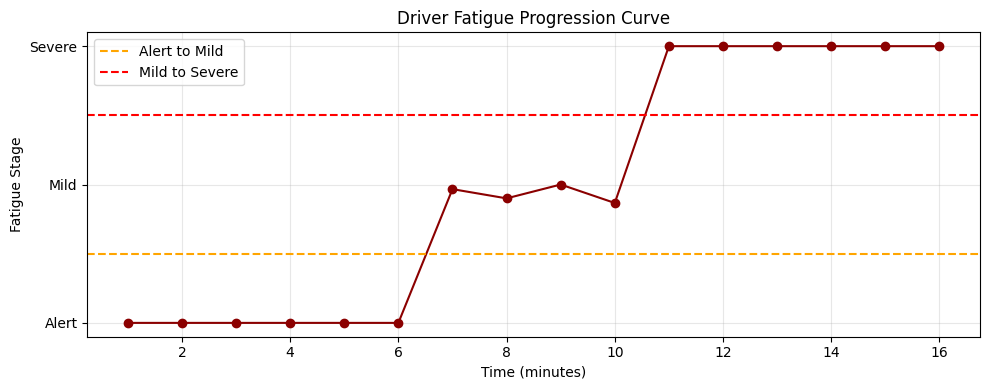

Alert to Mild transition at minute: 7
Mild to Severe transition at minute: 11


In [43]:
minutes = simulate_session(mobilenet, session, frames_per_min=30)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(minutes) + 1), minutes, marker="o", color="darkred")
plt.axhline(0.5, color="orange", ls="--", label="Alert to Mild")
plt.axhline(1.5, color="red", ls="--", label="Mild to Severe")
plt.yticks([0, 1, 2], ["Alert", "Mild", "Severe"])
plt.xlabel("Time (minutes)")
plt.ylabel("Fatigue Stage")
plt.title("Driver Fatigue Progression Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

first_mild = next((i + 1 for i, v in enumerate(minutes) if v >= 0.5), None)
first_severe = next((i + 1 for i, v in enumerate(minutes) if v >= 1.5), None)
print("Alert to Mild transition at minute:", first_mild)
print("Mild to Severe transition at minute:", first_severe)

In [44]:
y_pred, y_true = get_preds(mobilenet, test_loader)

per_class = pd.DataFrame({
    "Precision": precision_score(y_true, y_pred, average=None),
    "Recall": recall_score(y_true, y_pred, average=None),
}, index=CLASSES)
print(per_class.round(3))

         Precision  Recall
Closed       1.000   1.000
Open         1.000   1.000
no_yawn      0.930   0.964
yawn         0.962   0.927


##Save Models

In [46]:
import json, torch
from google.colab import files

torch.save(mobilenet.state_dict(), "mobilenetv2_fatigue.pth")

with open("classes.json", "w") as f:
    json.dump({
        "classes": CLASSES,
        "cls2idx": CLS2IDX,
        "idx2stage": {str(k): v for k, v in IDX2STAGE.items()},
        "stage_labels": STAGE_LABELS
    }, f, indent=2)

files.download("mobilenetv2_fatigue.pth")
files.download("classes.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>